# Vehicle Loan Default Prediction with ML, using boosting and bagging

From the fraud detection datasets, most common can be obtained from Amazon benchmark:
https://github.com/amazon-science/fraud-dataset-benchmark?tab=readme-ov-file#data-sources

We chose the Vehicle Loan Default Prediction because of the difficulty of these dataset and because the accuracy of implemented solutions are relatively low with respect to the other benchmark datasets.
https://www.kaggle.com/datasets/avikpaul4u/vehicle-loan-default-prediction/data


### About dataset
Financial institutions incur significant losses due to the default of vehicle loans. This has led to the tightening up of vehicle loan underwriting and increased vehicle loan rejection rates. The need for a better credit risk scoring model is also raised by these institutions. This warrants a study to estimate the determinants of vehicle loan default.
A financial institution has hired you to accurately predict the probability of loanee/borrower defaulting on a vehicle loan in the first EMI (Equated Monthly Instalments) on the due date. Following Information regarding the loan and loanee are provided:

- Loanee Information (Demographic data like age, income, Identity proof etc.)
- Loan Information (Disbursal details, amount, EMI, loan to value ratio etc.)
- Bureau data & history (Bureau score, number of active accounts, the status of other loans, credit history etc.)

Doing so will ensure that clients capable of repayment are not rejected and important determinants can be identified which can be further used for minimising the default rates.

# 1 Exploratory data analysis and cleaning

From the dictionary, the variables in this dataset are the following.
Note: Primary accounts are those which the customer has taken for his personal use. Secondary accounts are those which the customer act as a co-applicant or gaurantor


| Variable Name       | Description                                              | Variable Name       | Description                                              |
| ------------------- | -------------------------------------------------------- |------------------- | -------------------------------------------------------- |
| UniqueID            | Identifier for customers                                 |PERFORM\_CNS.SCORE                  | Bureau Score                               |
| loan\_default       | Payment default in the first EMI on due date             |PERFORM\_CNS.SCORE.DESCRIPTION      | Bureau score description                   |
| disbursed\_amount   | Amount of Loan disbursed                                 |PRI.NO.OF.ACCTS                     | Number of prior loans                      |
| asset\_cost         | Cost of the Asset                                        |PRI.ACTIVE.ACCTS                    | Number of active prior loans               |
| ltv                 | Loan to Value of the asset                               |PRI.OVERDUE.ACCTS                   | Number of overdue prior loans              |
| branch\_id          | Branch where the loan was disbursed                      |PRI.CURRENT.BALANCE                 | Principal outstanding of prior loans       |
| supplier\_id        | Vehicle Dealer where the loan was disbursed              |PRI.SANCTIONED.AMOUNT               | Total sanctioned amount of prior loans     |
| manufacturer\_id    | Vehicle manufacturer (Hero, Honda, TVS etc.)             | PRI.DISBURSED.AMOUNT                | Total disbursed amount of prior loans      |
| Current\_pincode    | Current pincode of the customer                          |SEC.NO.OF.ACCTS                     | Number of secondary loans                  |
| Date.of.Birth       | Date of birth of the customer                            |SEC.ACTIVE.ACCTS                    | Number of active secondary loans           |
| Employment.Type     | Employment Type of the customer (Salaried/Self Employed) |SEC.OVERDUE.ACCTS                   | Number of overdue secondary loans          |
| DisbursalDate       | Date of disbursement                                     |SEC.CURRENT.BALANCE                 | Principal outstanding of secondary loans   |
| State\_ID           | State of disbursement                                    |SEC.SANCTIONED.AMOUNT               | Total sanctioned amount of secondary loans |
| Employee\_code\_ID  | Employee of the organization who logged the disbursement |SEC.DISBURSED.AMOUNT                | Total disbursed amount of secondary loans  |
| MobileNo\_Avl\_Flag | If mobile number was shared (1 if yes)                   |PRIMARY.INSTAL.AMT                  | EMI of the primary loan                    |
| Aadhar\_flag        | If Aadhar was shared (1 if yes)                          |SEC.INSTAL.AMT                      | EMI of the secondary loan                  |
| PAN\_flag           | If PAN was shared (1 if yes)                             |NEW\.ACCTS.IN.LAST.SIX.MONTHS       | New loans in last 6 months                 |
| VoterID\_flag       | If Voter ID was shared (1 if yes)                        |DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS | Defaults in last 6 months                  |
| Driving\_flag       | If Driving License was shared (1 if yes)                 |AVERAGE.ACCT.AGE                    | Average loan tenure                        |
| Passport\_flag      | If Passport was shared (1 if yes)                        |CREDIT.HISTORY.LENGTH               | Time since first loan                      |
| NO.OF\_INQUIRIES                    | Number of loan inquiries                   |NO.OF\_INQUIRIES                    | Number of loan inquiries                   |


We perform some checks in the df and the provide a function to clean the dataset.

In [1]:
import numpy as np
import pandas as pd
#Checking the type of each variable and NA values

def check_pd(df):
    print(df.info())    
    print("NA present",sum(df["EMPLOYMENT_TYPE"].isna()))
    print("Percentage",sum(df["EMPLOYMENT_TYPE"].isna())/df["EMPLOYMENT_TYPE"].count())
    
    return

check_pd(pd.read_csv("train.csv"))
check_pd(pd.read_csv("test.csv"))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 41 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   UNIQUEID                             233154 non-null  int64  
 1   DISBURSED_AMOUNT                     233154 non-null  int64  
 2   ASSET_COST                           233154 non-null  int64  
 3   LTV                                  233154 non-null  float64
 4   BRANCH_ID                            233154 non-null  int64  
 5   SUPPLIER_ID                          233154 non-null  int64  
 6   MANUFACTURER_ID                      233154 non-null  int64  
 7   CURRENT_PINCODE_ID                   233154 non-null  int64  
 8   DATE_OF_BIRTH                        233154 non-null  object 
 9   EMPLOYMENT_TYPE                      225493 non-null  object 
 10  DISBURSAL_DATE                       233154 non-null  object 
 11  STATE_ID     



We will change the object type variables to a more convenient numerical format. For the date we will take the date established in the dataset from Kaggle, this is 21 of april 2019.
- The EMPLOYMENT_TYPE column has NA values in both datasets, and is the only one with this type of data, we just add a new category for this type of data by encoding.
- We drop the PERFORM_CNS_SCORE_DESCRIPTION as this variable is already encoded in the PERFORM_CNS_SCORE
- We tranform to float the dates or time periods in AVERAGE_ACCT_AGE, CREDIT_HISTORY_LENGTH, DATE_OF_BIRTH
- We drop the DISBURSAL_DATE as we have only a month worth of data and is not sufficient to capture time dynamics.


In [2]:
from sklearn.preprocessing import LabelEncoder
import re

def clean_dataframe(df):
    
    df["DATE_OF_BIRTH"] = pd.to_datetime(df["DATE_OF_BIRTH"],errors ="coerce",dayfirst=True)
    df["AGE"] = ((pd.to_datetime('2019-04-21') - df["DATE_OF_BIRTH"])).dt.days.astype(float)/365
    encoder = LabelEncoder()
    df["EMPLOYMENT_TYPE_NUM"] = encoder.fit_transform(df["EMPLOYMENT_TYPE"])

    def string_to_months(s):
        match = re.findall(r'\d+', s)
        if len(match) == 2:
            years, months = map(int, match)
        return years*12 + months

    df["CREDIT_HISTORY_MONTHS"] = df["CREDIT_HISTORY_LENGTH"].apply(string_to_months)
    df["AVERAGE_ACCT_MONTHS"] = df["AVERAGE_ACCT_AGE"].apply(string_to_months)
    
    df=df.drop(["DISBURSAL_DATE","PERFORM_CNS_SCORE_DESCRIPTION",
             "DATE_OF_BIRTH","EMPLOYMENT_TYPE","CREDIT_HISTORY_LENGTH","AVERAGE_ACCT_AGE"],axis=1)
    return df



In [3]:
df_train=clean_dataframe(pd.read_csv("train.csv"))
df_test=clean_dataframe(pd.read_csv("test.csv"))


In [4]:
pd.set_option('display.max_columns', None)
df_train.describe(include="all")

,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,STATE_ID,EMPLOYEE_CODE_ID,MOBILENO_AVL_FLAG,AADHAR_FLAG,PAN_FLAG,VOTERID_FLAG,DRIVING_FLAG,PASSPORT_FLAG,PERFORM_CNS_SCORE,PRI_NO_OF_ACCTS,PRI_ACTIVE_ACCTS,PRI_OVERDUE_ACCTS,PRI_CURRENT_BALANCE,PRI_SANCTIONED_AMOUNT,PRI_DISBURSED_AMOUNT,SEC_NO_OF_ACCTS,SEC_ACTIVE_ACCTS,SEC_OVERDUE_ACCTS,SEC_CURRENT_BALANCE,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,NO_OF_INQUIRIES,LOAN_DEFAULT,AGE,EMPLOYMENT_TYPE_NUM,CREDIT_HISTORY_MONTHS,AVERAGE_ACCT_MONTHS
count,233154.000000,233154.000000,2.331540e+05,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.0,233154.00000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,2.331540e+05,2.331540e+05,2.331540e+05,233154.000000,233154.000000,233154.000000,2.331540e+05,2.331540e+05,2.331540e+05,2.331540e+05,2.331540e+05,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000
mean,535917.573376,54356.993528,7.586507e+04,74.746530,72.936094,19638.635035,69.028054,3396.880247,7.262243,1549.477148,1.0,0.84032,0.075577,0.144943,0.023242,0.002127,289.462994,2.440636,1.039896,0.156549,1.659001e+05,2.185039e+05,2.180659e+05,0.059081,0.027703,0.007244,5.427793e+03,7.295923e+03,7.179998e+03,1.310548e+04,3.232684e+02,0.381833,0.097481,0.206615,0.217071,35.067974,0.613144,16.252404,8.915764
std,68315.693711,12971.314171,1.894478e+04,11.456636,69.834995,3491.949566,22.141304,2238.147502,4.482230,975.261278,0.0,0.36631,0.264320,0.352044,0.150672,0.046074,338.374779,5.217233,1.941496,0.548787,9.422736e+05,2.374794e+06,2.377744e+06,0.626795,0.316057,0.111079,1.702370e+05,1.831560e+05,1.825925e+05,1.513679e+05,1.555369e+04,0.955107,0.384439,0.706498,0.412252,9.830786,0.550378,28.581255,15.106416
min,417428.000000,13320.000000,3.700000e+04,10.030000,1.000000,10524.000000,45.000000,1.000000,1.000000,1.000000,1.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.678296e+06,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,-5.746470e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,18.512329,0.000000,0.000000,0.000000
25%,476786.250000,47145.000000,6.571700e+04,68.880000,14.000000,16535.000000,48.000000,1511.000000,4.000000,713.000000,1.0,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,26.939726,0.000000,0.000000,0.000000
50%,535978.500000,53803.000000,7.094600e+04,76.800000,61.000000,20333.000000,86.000000,2970.000000,6.000000,1451.000000,1.0,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,33.323288,1.000000,0.000000,0.000000
75%,595039.750000,60413.000000,7.920175e+04,83.670000,130.000000,23000.000000,86.000000,5677.000000,10.000000,2362.000000,1.0,1.00000,0.000000,0.000000,0.000000,0.000000,678.000000,3.000000,1.000000,0.000000,3.500650e+04,6.250000e+04,6.080000e+04,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.999000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000,41.991781,1.000000,24.000000,13.000000
max,671084.000000,990572.000000,1.628992e+06,95.000000,261.000000,24803.000000,156.000000,7345.000000,22.000000,3795.000000,1.0,1.00000,1.000000,1.000000,1.000000,1.000000,890.000000,453.000000,144.000000,25.000000,9.652492e+07,1.000000e+09,1.000000e+09,52.000000,36.000000,8.000000,3.603285e+07,3.000000e+07,3.000000e+07,2.564281e+07,4.170901e+06,35.000000,20.000000

We proceeed to scale the data thats not categorical using Robust Scaler and IQR so to handle outliers.

In [5]:
from sklearn.preprocessing import RobustScaler

def scale_df(df_train,df_test):
    
    # Identify numeric categorical columns
    num_cat_cols = {'UNIQUEID','BRANCH_ID','SUPPLIER_ID','MANUFACTURER_ID','CURRENT_PINCODE_ID',
                    'STATE_ID','EMPLOYEE_CODE_ID','MOBILENO_AVL_FLAG','AADHAR_FLAG','PAN_FLAG',
                    'VOTERID_FLAG','DRIVING_FLAG','PASSPORT_FLAG','LOAN_DEFAULT','EMPLOYMENT_TYPE'}
    # Substract numeric continuous columns
    num_cont_cols = df_train.select_dtypes(include='number').columns.difference(num_cat_cols)
    
    df_train_scaled, df_test_scaled = df_train.copy(), df_test.copy()
    #quantiles only on train
    q1, q99 = df_train[num_cont_cols].quantile(0.01), df_train[num_cont_cols].quantile(0.99)
    
    for df_ in (df_train_scaled, df_test_scaled):
        #flags dataframe with booleans to integers where we are lower or higher than the quantile
        flags = ((df_[num_cont_cols].lt(q1)) | (df_[num_cont_cols].gt(q99))).astype(int)
        # save them with flag in the name
        flags.columns = [f"{c}_winflag" for c in flags.columns]
        #clipping the values
        df_[num_cont_cols] = df_[num_cont_cols].clip(q1, q99, axis=1)
        #df_[flags.columns] = flags #optional adding the winflags as columns

    scaler = RobustScaler().fit(df_train_scaled[num_cont_cols])   # fit ONLY on (winsorized) train
    df_train_scaled[num_cont_cols] = scaler.transform(df_train_scaled[num_cont_cols])
    df_test_scaled[num_cont_cols]  = scaler.transform(df_test_scaled[num_cont_cols])

    return df_train_scaled, df_test_scaled, scaler

In [6]:
df_train_scaled, df_test_scaled, scaler = scale_df(df_train, df_test)

In [7]:
pd.set_option('display.max_columns', None)
df_train_scaled.describe(include="all")

,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,STATE_ID,EMPLOYEE_CODE_ID,MOBILENO_AVL_FLAG,AADHAR_FLAG,PAN_FLAG,VOTERID_FLAG,DRIVING_FLAG,PASSPORT_FLAG,PERFORM_CNS_SCORE,PRI_NO_OF_ACCTS,PRI_ACTIVE_ACCTS,PRI_OVERDUE_ACCTS,PRI_CURRENT_BALANCE,PRI_SANCTIONED_AMOUNT,PRI_DISBURSED_AMOUNT,SEC_NO_OF_ACCTS,SEC_ACTIVE_ACCTS,SEC_OVERDUE_ACCTS,SEC_CURRENT_BALANCE,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,NO_OF_INQUIRIES,LOAN_DEFAULT,AGE,EMPLOYMENT_TYPE_NUM,CREDIT_HISTORY_MONTHS,AVERAGE_ACCT_MONTHS
count,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.0,233154.00000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.0,233154.000000,233154.000000,233154.000000,233154.000000,233154.0,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000
mean,535917.573376,0.036108,0.353382,-0.135835,72.936094,19638.635035,69.028054,3396.880247,7.262243,1549.477148,1.0,0.84032,0.075577,0.144943,0.023242,0.002127,0.426855,0.774828,1.011036,0.139736,3.796215,2.781985,2.845991,0.035444,0.016371,0.0,228.248891,656.220498,612.423658,3.730586,0.0,0.359655,0.091995,0.187001,0.217071,0.115072,-0.386856,0.666086,0.666391
std,68315.693711,0.907645,1.293996,0.758856,69.834995,3491.949566,22.141304,2238.147502,4.482230,975.261278,0.0,0.36631,0.264320,0.352044,0.150672,0.046074,0.498944,1.400366,1.731847,0.417487,12.302392,8.333982,8.549276,0.234023,0.126898,0.0,2050.352586,5473.397488,5161.660430,15.842012,0.0,0.806174,0.333834,0.537098,0.412252,0.649049,0.550378,1.128545,1.046544
min,417428.000000,-2.055623,-1.768403,-2.538878,1.000000,10524.000000,45.000000,1.000000,1.000000,1.000000,1.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,-0.860393,-1.000000,0.000000,0.000000
25%,476786.250000,-0.501809,-0.387771,-0.535497,14.000000,16535.000000,48.000000,1511.000000,4.000000,713.000000,1.0,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,-0.424099,-1.000000,0.000000,0.000000
50%,535978.500000,0.000000,0.000000,0.000000,61.000000,20333.000000,86.000000,2970.000000,6.000000,1451.000000,1.0,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,595039.750000,0.498191,0.612229,0.464503,130.000000,23000.000000,86.000000,5677.000000,10.000000,2362.000000,1.0,1.00000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.575901,0.000000,1.000000,1.000000
max,671084.000000,3.134459,6.308608,0.889114,261.000000,24803.000000,156.000000,7345.000000,22.000000,3795.000000,1.0,1.00000,1.000000,1.000000,1.000000,1.000000,1.233038,7.666667,9.000000,2.000000,83.352073,55.473910,56.867991,2.000000,1.000000,0.0,19733.780000,50000.000000,47544.830000,128.143762,0.0,4.000000,2.000000,3.000000,1.000000,1.734256,1.000000,5.833333,5.230769


In [8]:
pd.set_option('display.max_columns', None)
df_test_scaled.describe(include="all")

,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,STATE_ID,EMPLOYEE_CODE_ID,MOBILENO_AVL_FLAG,AADHAR_FLAG,PAN_FLAG,VOTERID_FLAG,DRIVING_FLAG,PASSPORT_FLAG,PERFORM_CNS_SCORE,PRI_NO_OF_ACCTS,PRI_ACTIVE_ACCTS,PRI_OVERDUE_ACCTS,PRI_CURRENT_BALANCE,PRI_SANCTIONED_AMOUNT,PRI_DISBURSED_AMOUNT,SEC_NO_OF_ACCTS,SEC_ACTIVE_ACCTS,SEC_OVERDUE_ACCTS,SEC_CURRENT_BALANCE,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,NO_OF_INQUIRIES,AGE,EMPLOYMENT_TYPE_NUM,CREDIT_HISTORY_MONTHS,AVERAGE_ACCT_MONTHS
count,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.0,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.0,112392.000000,112392.000000,112392.000000,112392.000000,112392.0,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000,112392.000000
mean,711741.891861,0.162867,0.448585,-0.098089,78.902591,19843.303545,68.366031,3014.001352,7.215754,1771.651541,1.0,0.869626,0.191588,0.120978,0.016709,0.001913,0.424899,0.716237,0.909397,0.136131,3.422330,2.510805,2.583862,0.015152,0.007429,0.0,108.086753,308.494457,286.680024,3.226187,0.0,0.299603,0.086047,0.204223,0.129306,-0.406719,0.636137,0.661442
std,33492.215991,0.911571,1.245201,0.729828,71.469633,3555.303301,22.137265,2223.215364,4.679847,1104.533635,0.0,0.336716,0.393553,0.326104,0.128181,0.043696,0.501052,1.319657,1.600599,0.412340,11.645660,7.881774,8.120389,0.152015,0.085873,0.0,1419.972068,3773.553187,3555.192691,14.371229,0.0,0.727505,0.323567,0.560188,0.655224,0.550063,1.089641,1.044388
min,654115.000000,-2.055623,-1.768403,-2.538878,1.000000,10524.000000,45.000000,1.000000,1.000000,1.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,-0.860393,-1.000000,0.000000,0.000000
25%,682658.750000,-0.373380,-0.254806,-0.461799,15.000000,16633.000000,45.000000,1312.000000,4.000000,801.000000,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,-0.423553,-1.000000,0.000000,0.000000
50%,711522.500000,0.117275,0.121471,0.066261,67.000000,20675.000000,86.000000,2412.000000,6.000000,1664.000000,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.018202,0.000000,0.000000,0.000000
75%,740851.250000,0.628882,0.674391,0.469236,136.000000,23170.000000,86.000000,5092.000000,10.000000,2694.000000,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,1.001475,0.666667,1.000000,0.000000,0.706297,0.816000,0.822368,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.927964,0.0,0.000000,0.000000,0.000000,0.598289,0.000000,0.958333,1.000000
max,769909.000000,3.134459,6.308608,0.889114,261.000000,24901.000000,155.000000,7345.000000,22.000000,3923.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.233038,7.666667,9.000000,2.000000,83.352073,55.473910,56.867991,2.000000,1.000000,0.0,19733.780000,50000.000000,47544.830000,128.143762,0.0,4.000000,2.000000,3.000000,1.734256,1.000000,5.833333,5.230769


We'll leave the especific encoding of categorical variables to change in each instance of model fitting. Lets take a look at the class balance.

In [9]:
class_df = df_train_scaled.groupby('LOAN_DEFAULT').count()['UNIQUEID'].reset_index().sort_values(by='UNIQUEID',ascending=False)
class_df

,LOAN_DEFAULT,UNIQUEID
0,0,182543
1,1,50611


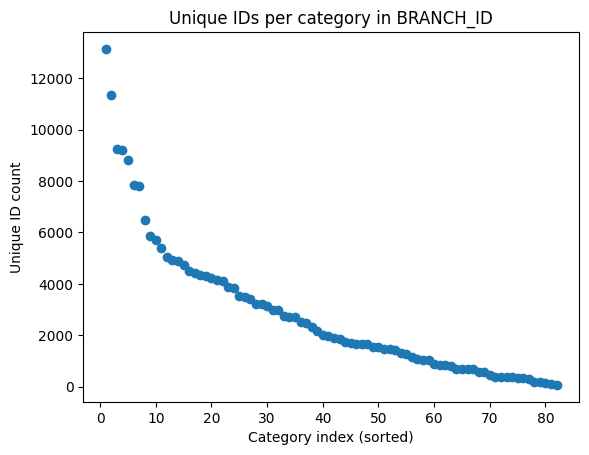

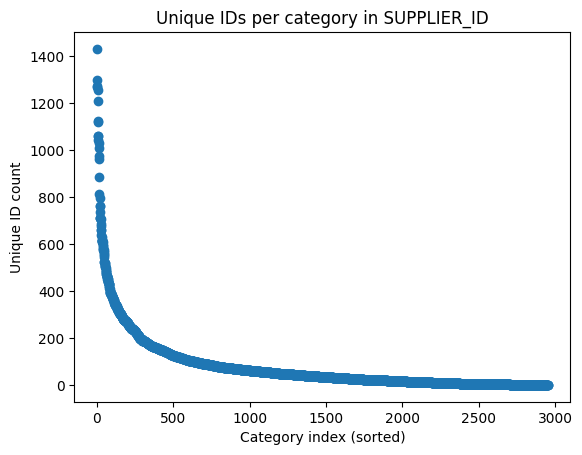

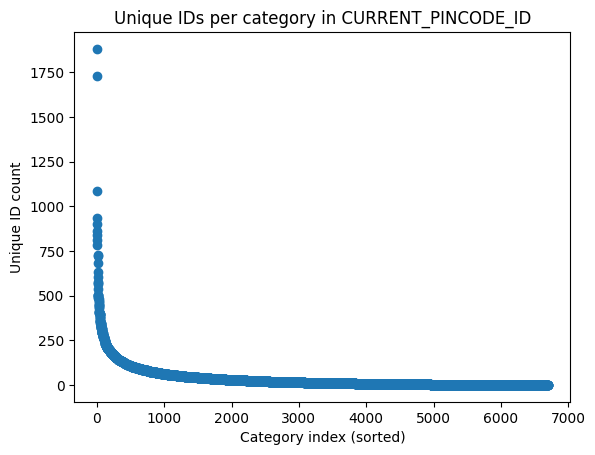

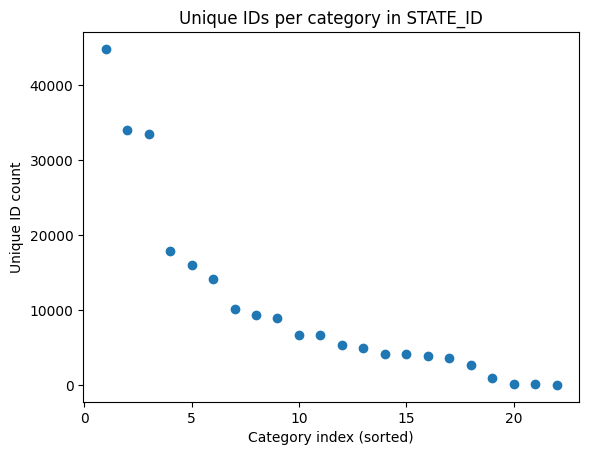

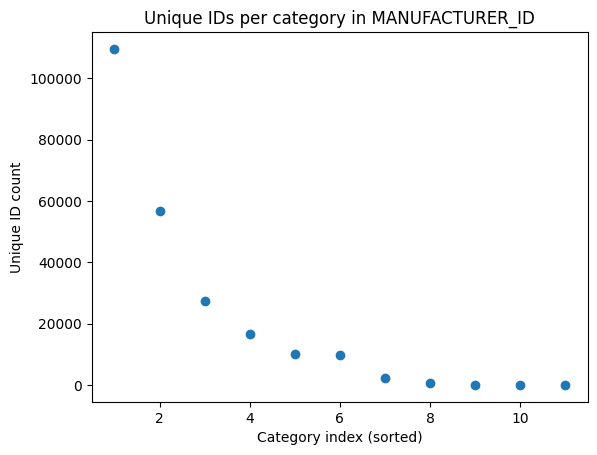

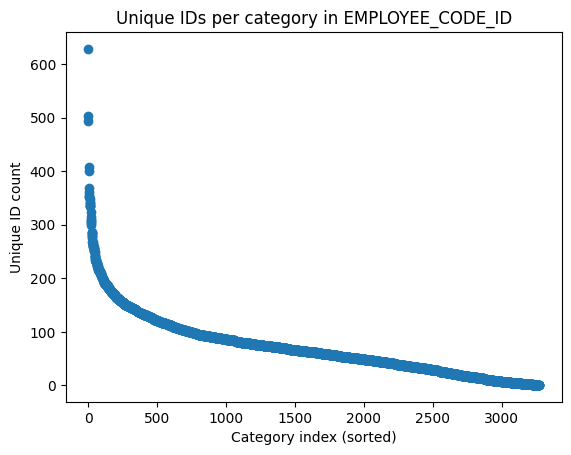

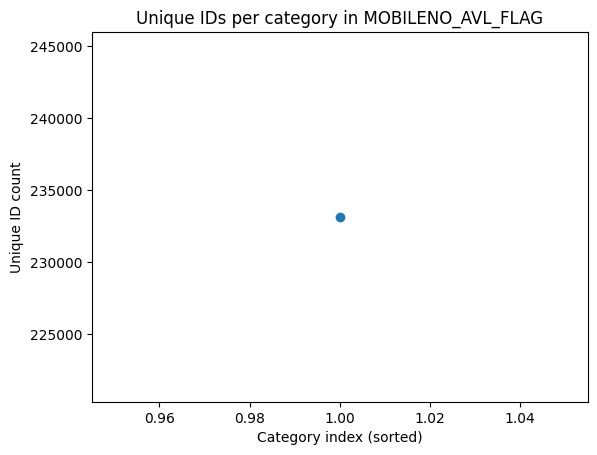

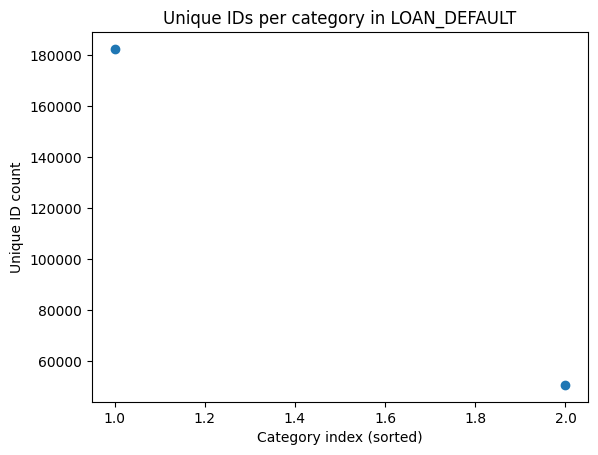

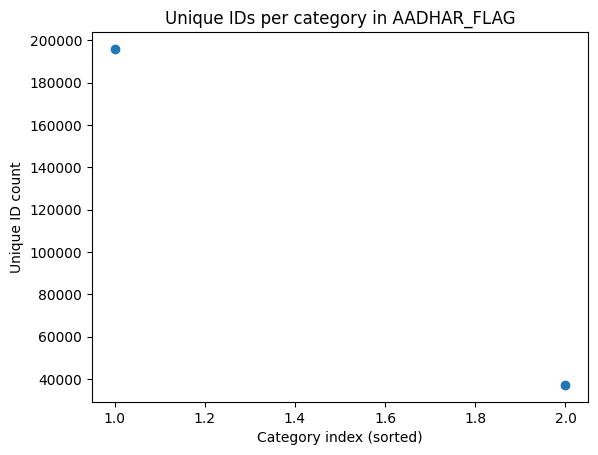

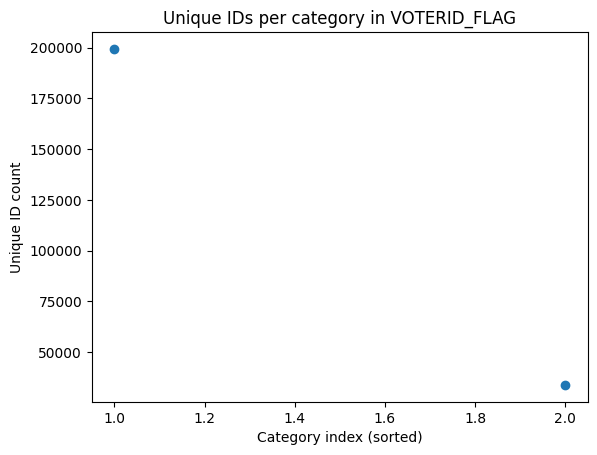

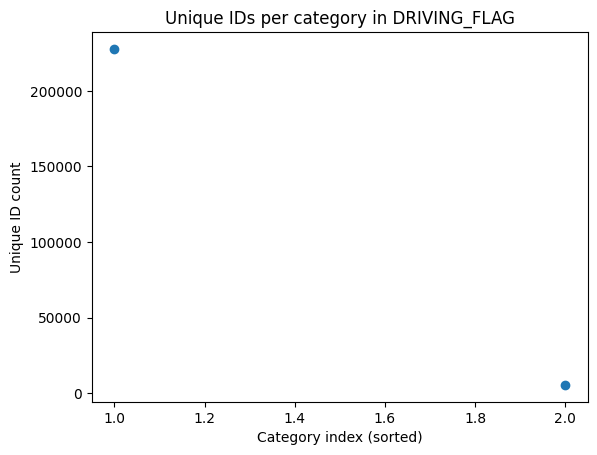

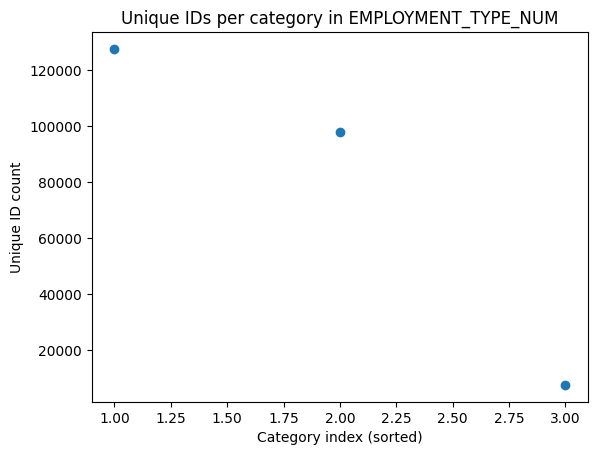

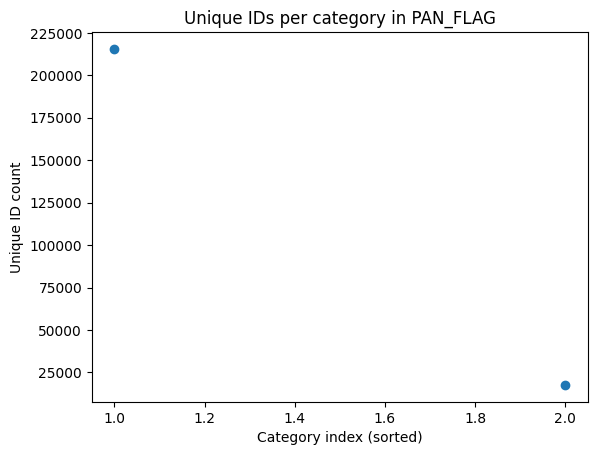

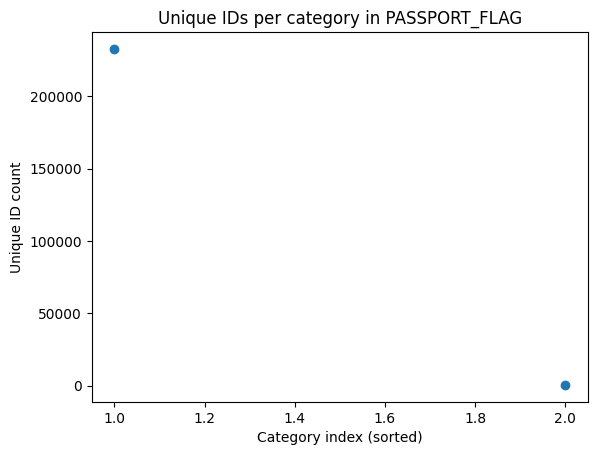

In [10]:
import matplotlib.pyplot as plt

num_cat_cols = {
    'BRANCH_ID','SUPPLIER_ID','MANUFACTURER_ID','CURRENT_PINCODE_ID',
    'STATE_ID','EMPLOYEE_CODE_ID','MOBILENO_AVL_FLAG','AADHAR_FLAG','PAN_FLAG',
    'VOTERID_FLAG','DRIVING_FLAG','PASSPORT_FLAG','LOAN_DEFAULT','EMPLOYMENT_TYPE_NUM'
}

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')
results = {}

for col in num_cat_cols:
    counts = df_train_scaled.groupby(col)['UNIQUEID'].nunique().reset_index(name='UNIQUE_ID').sort_values(by='UNIQUE_ID',ascending=False)
    # X = category index (1, 2, 3, ...)
    x = np.arange(1, len(counts) + 1)
    # Y = number of unique IDs
    y = counts['UNIQUE_ID']

    plt.scatter(x, y)
    plt.title(f"Unique IDs per category in {col}")
    plt.xlabel("Category index (sorted)")
    plt.ylabel("Unique ID count")
    plt.show()
    



Lets check mutual information and pearson correlation to determine the most important variables or if some have a certain relationship.

### Pearson Correlation Coefficient

Given two variables  $X = (x_1, x_2, ..., x_n), Y = (y_1, y_2, ..., y_n)$

the Pearson correlation coefficient r is calculated as:

$$ r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \cdot \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}} $$

In other words, it is the **covariance between X and Y** divided by the product of their standard deviations:
$$r = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y}$$
- $\bar{x}$ and $ \bar{y} $ are the means of $X $ and $ Y $.
- $\sigma_X $ and $ \sigma_Y $ are their standard deviations.
- $ r \in [-1, 1] $ indicates the strength and direction of a **linear** relationship between the two variables.

In scipy pearson correlation the function will return r, the correlation coefficient, and the p value. This last P value refers to the probability of having observed a certain correlation value assuming a Null Hypothesis "There is no correlation between X and Y".
For instance, a p value smaller than a certain treshold would provide eviden to reject the null hypothesis and suggest a correlation between X and Y.

### Mutual information
Mutual information comes from information theory. It is a measure of how often two events x and y occur, compared with what we would expect if they were independent. Then is a masure of the mutual dependence between the two variables.

More specifically, it quantifies the amount of inofrmation obtained about one randome variable by observing the other random variable. The MI is not limited to linear relationships like Pearson, and is a more general measure that determines how different the joint distribuition of (X,Y) is from the product of marginal distribution of X and Y. 

Its the kullback leibler divergence distance between both distributions (X,Y) and XxY, if they are closer means the depend on each other.

$$I(X ; Y)=\sum_{x \in X} \sum_{y \in Y} p(x, y) \log \left(\frac{p(x, y)}{p(x) p(y)}\right)$$

The numerator inside the log tells us how often we observed the two events together, and the denominator tells us how often we would expect the two events to co-occur assuming they each occured indepedently.

The MI is zero when both variables are independent. In sklearn, the mutual info returns the value of MI.



Both still work when comparing a binary variable like Y in this case.
For the Peasron correlation the covariance is the same as a Bernoulli variable (0,1 with certain p).
For the mutual information its not necessary to make this distinction, as in any case the probability of joint and independent events is easily obtained.

                                feature  pearson_r        p_value  \
0                      DISBURSED_AMOUNT   0.083991   0.000000e+00   
1                                   LTV   0.099238   0.000000e+00   
2                     PERFORM_CNS_SCORE  -0.057895  2.983845e-172   
3                            ASSET_COST   0.016313   3.340218e-15   
4                  PRI_DISBURSED_AMOUNT  -0.050081  2.389537e-129   
5                                   AGE  -0.035934   1.758052e-67   
6                       PRI_NO_OF_ACCTS  -0.042079   7.396478e-92   
7                 PRI_SANCTIONED_AMOUNT  -0.050760  7.905420e-133   
8                     PRI_OVERDUE_ACCTS   0.048640  4.067361e-122   
9                   PRI_CURRENT_BALANCE  -0.045487  4.991039e-107   
10                     PRI_ACTIVE_ACCTS  -0.042944   1.348505e-95   
11                      NO_OF_INQUIRIES   0.045031  6.269005e-105   
12                  AVERAGE_ACCT_MONTHS  -0.026379   3.572207e-37   
13                CREDIT_HISTORY_M

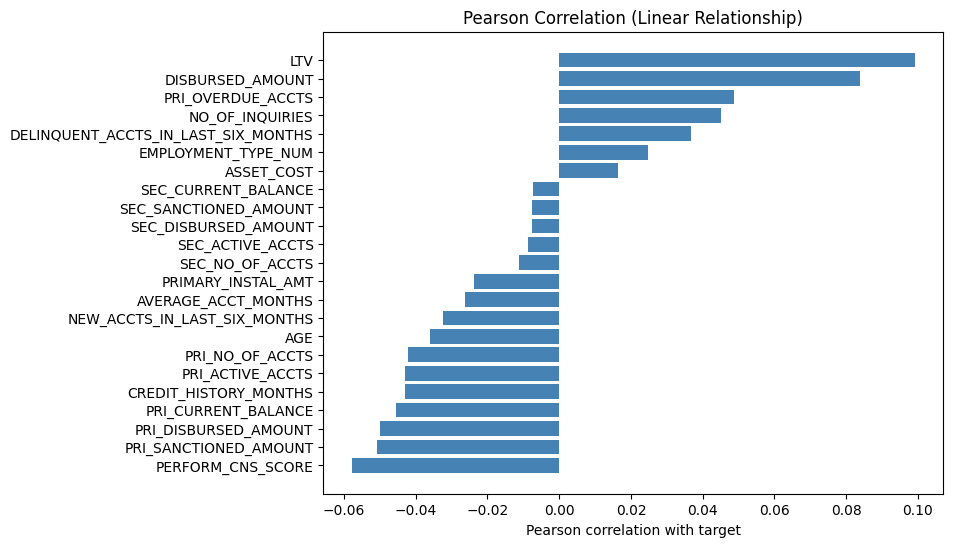

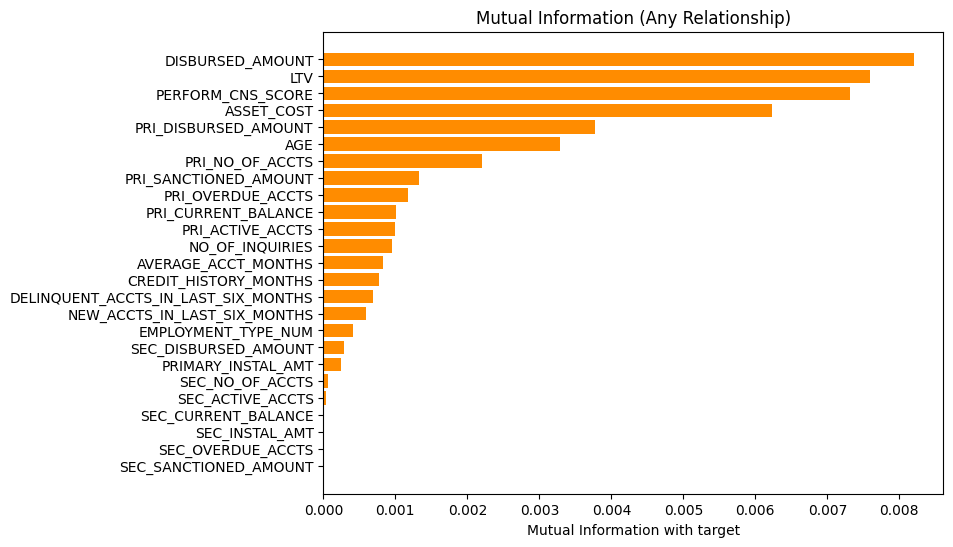

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_classif


#Dataset without ID
# Split into features and label
def drop_categorical(df):
    df_no_cat=df.copy()
    num_cat_cols = {'UNIQUEID','BRANCH_ID','SUPPLIER_ID','MANUFACTURER_ID','CURRENT_PINCODE_ID',
                        'STATE_ID','EMPLOYEE_CODE_ID','MOBILENO_AVL_FLAG','AADHAR_FLAG','PAN_FLAG',
                        'VOTERID_FLAG','DRIVING_FLAG','PASSPORT_FLAG','EMPLOYMENT_TYPE'}
        # Substract numeric continuous columns
    num_cont_cols = df_train.select_dtypes(include='number').columns.difference(num_cat_cols)
    df_no_cat= df[num_cont_cols] 
    return df_no_cat

X = drop_categorical(df_train_scaled)
X = X.drop(columns=["LOAN_DEFAULT"])
y = df_train_scaled["LOAN_DEFAULT"]

# --- 1) Pearson correlation (numeric-only), with Bonferroni ---
pearson_results = []
num_cols = X.select_dtypes(include='number').columns.tolist()

for col in num_cols:
    x = X[col].astype(float)
    mask = np.isfinite(x) & np.isfinite(y)
    if x[mask].nunique() < 2: #all data are finite to avoid num errors, there are not constant values
        continue
    r, p = pearsonr(x[mask], y[mask])  # point-biserial when y is binary
    pearson_results.append((col, r, p))

pearson_df = pd.DataFrame(pearson_results, columns=['feature', 'pearson_r', 'p_value'])
m = max(len(pearson_df), 1)                # number of tests #avoid dividion by 0
alpha = 0.05
alpha_bonf = alpha / m

pearson_df['p_bonf']  = np.minimum(pearson_df['p_value'] * m, 1.0) #real p value adjusted by num of tests
pearson_df['alpha']   = alpha
pearson_df['alpha_bonf'] = alpha_bonf
pearson_df['sig_bonf']   = pearson_df['p_value'] < alpha_bonf #compare to adjusted alpha in bonferroni

# --- 2) Mutual Information (numeric + categorical) ---
cat_mask = X.nunique() < 20  # treat low-cardinality cols as discrete
mi_scores = mutual_info_classif(X, y, discrete_features=cat_mask.tolist(), random_state=42)
mi_df = pd.DataFrame({'feature': X.columns, 'mutual_info': mi_scores})

# --- 3) Merge & view ---
comparison_df = (pd.merge(pearson_df, mi_df, on='feature', how='outer')
                   .sort_values(['sig_bonf','mutual_info'], ascending=[False, False])
                   .reset_index(drop=True))

print(comparison_df)
# --- 4. Plot Pearson correlation ---
pearson_plot_df = pearson_df.sort_values(by='pearson_r', ascending=False)
plt.figure(figsize=(8, 6))
plt.barh(pearson_plot_df['feature'], pearson_plot_df['pearson_r'], color='steelblue')
plt.xlabel("Pearson correlation with target")
plt.title("Pearson Correlation (Linear Relationship)")
plt.gca().invert_yaxis()
plt.show()

# --- 5. Plot Mutual Information ---
mi_plot_df = mi_df.sort_values(by='mutual_info', ascending=False)
plt.figure(figsize=(8, 6))
plt.barh(mi_plot_df['feature'], mi_plot_df['mutual_info'], color='darkorange')
plt.xlabel("Mutual Information with target")
plt.title("Mutual Information (Any Relationship)")
plt.gca().invert_yaxis()
plt.show()


from the 39 starting variables we will keep only the following 15, based on their MI and correlation. (with +- the type of correlation) without the ID variables.

1. DISBURSED_AMOUNT +
2. LTV +
3. PERFORM_CNS_SCORE -
4. ASSET_COST +
5. PRI_DISBURSED_AMOUNT -
6. AGE -
7. PRI_NO_OF_ACCTS -
8. PRI_SANCTIONED_AMOUNT -
9. PRI_OVERDUE_ACCTS +
10. PRI_CURRENT_BALANCE -
11. PRI_ACTIVATE_ACCTS -
12. NO_OF_INQUIRIES +
13. AVERAGE_ACCT_MONTHS -
14. CREDIT_HISTORY_MONTHS -
15. DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS +

In [12]:
from sklearn.model_selection import train_test_split

def drop_variables(df):
    df_no_cat=df.copy()
    num_cat_cols = {'UNIQUEID','BRANCH_ID','SUPPLIER_ID','MANUFACTURER_ID','CURRENT_PINCODE_ID',
                        'STATE_ID','EMPLOYEE_CODE_ID','MOBILENO_AVL_FLAG','AADHAR_FLAG','PAN_FLAG',
                        'VOTERID_FLAG','DRIVING_FLAG','PASSPORT_FLAG','EMPLOYMENT_TYPE',
                        'NEW_ACCTS_IN_LAST_SIX_MONTHS','EMPLOYMENT_TYPE_NUM','SEC_DISBURSED_AMOUNT',
                        'PRIMARY_INSTAL_AMT','SEC_NO_OF_ACCTS','SEC_ACTIVE_ACCTS','SEC_CURRENT_BALANCE',
                        'SEC_SANCTIONED_AMOUNT','SEC_INSTAL_AMT','SEC_OVERDUE_ACCTS'
                        }

        # Substract numeric continuous columns
    num_cont_cols = df_train.select_dtypes(include='number').columns.difference(num_cat_cols)
    df_no_cat= df[num_cont_cols] 
    return df_no_cat

X = drop_variables(df_train_scaled)
X = X.drop(columns=["LOAN_DEFAULT"])
y = df_train_scaled["LOAN_DEFAULT"]


# Train/validation split (80% train, 20% validation)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify keeps label distribution balanced
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_valid.shape, y_valid.shape)


Train shape: (186523, 15) (186523,)
Validation shape: (46631, 15) (46631,)


# Model prediction

In this example well use a variety of models for the objective task. We also plan on using bagging and boosting.

Bagging: Bootstrap aggregating. Given a dataset, instead of training one classifier on the entire dataset, we sample with replacement to create different datasets, called bootstraps. Then we train a weak model, for regression or classification, on each of these bootstraps. The sampling with replacement allow for each model to be independent from the other one.

We well try the following models with bagging: 

- Logistic regression 
- KNN nearest neighbor
- Random forest (Decision tree ensemble)

Boosting: algorithm to convert weak learners into strong ones. Each learner in this ensemble is trained on the same set of samples, but samples are weighted differently among iterations. Future weak learners focuse more on the examples that previous weak learners misclasified.

With boosting we'll try:
- Ada boost
- Gradient boosting machine classifier
- XG Boost
- Cat boost classifier



## Bagging

## Logistic Regression

Logistic Regression is a linear model used for binary or multiclass classification.
Instead of predicting a continuous value, it estimates the probability that a given input belongs to a certain class using the logistic (sigmoid) function:

$$  P(y=1|X)= \frac{1}{1+ e^{-wX+b}}
$$

We are
Binary classification: predicts class 0 or 1 based on a threshold (default 0.5).

Multiclass classification: in scikit-learn, handled via one-vs-rest by default, or multinomial with solver='lbfgs' or similar.

Key parameters in sklearn.linear_model.LogisticRegression:
penalty: Regularization type ('l2', 'l1', 'elasticnet', or 'none').

C: Inverse of regularization strength (smaller = stronger regularization).

solver: Optimization algorithm ('lbfgs', 'liblinear', 'saga', etc.).

max_iter: Maximum iterations for convergence.

Logistic Regression in scikit-learn supports probability outputs and works well as a baseline classifier when features are properly scaled. The training process is about finding the weights W for that plane of separation. 

As this is a distance based algorithm, we will drop the personal IDs as they dont represent a distance based characteristic.

Accuracy     : 0.7828
Precision    : 0.4649
Recall       : 0.0052
F1-score     : 0.0104
ROC-AUC      : 0.6125
PR-AUC (AP)  : 0.2920
PR-AUC (area): 0.2919

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.78      1.00      0.88     36509
           1       0.46      0.01      0.01     10122

    accuracy                           0.78     46631
   macro avg       0.62      0.50      0.44     46631
weighted avg       0.71      0.78      0.69     46631

=== Confusion Matrix ===
[[36448    61]
 [10069    53]]


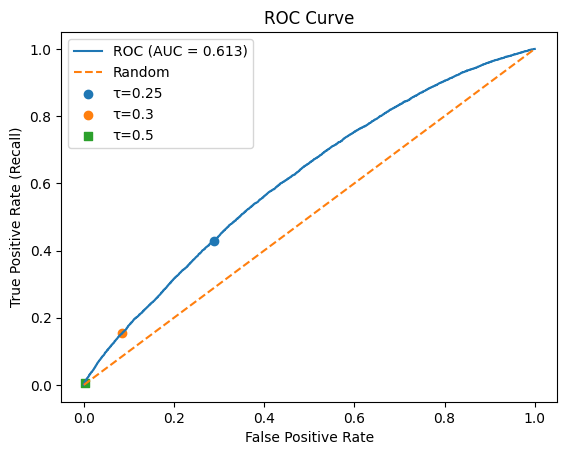

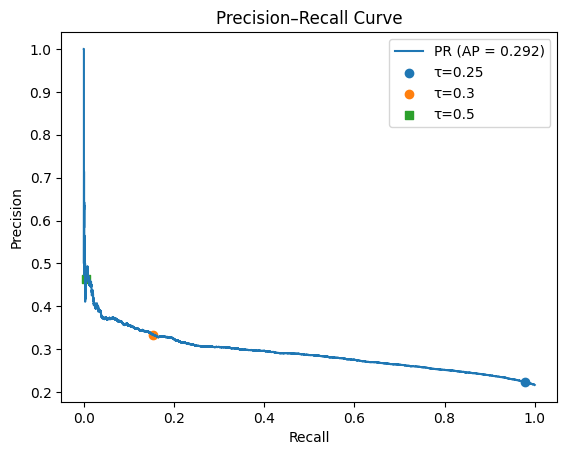

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, auc, confusion_matrix, classification_report)

# --- Train ---
log_reg = LogisticRegression(max_iter=10000, solver='lbfgs', n_jobs=-1)
log_reg.fit(X_train, y_train)

# --- Probabilities & thresholded preds ---
y_proba = log_reg.predict_proba(X_valid)[:, 1]
threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)

# --- Scalar metrics ---
acc = accuracy_score(y_valid, y_pred)
prec = precision_score(y_valid, y_pred, zero_division=0)
rec = recall_score(y_valid, y_pred, zero_division=0)
f1 = f1_score(y_valid, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_valid, y_proba)

# PR-AUC options: AP (preferred in sklearn) and literal area under PR curve
prec_curve, rec_curve, pr_thr = precision_recall_curve(y_valid, y_proba)
ap = average_precision_score(y_valid, y_proba)       # "PR-AUC" in sklearn parlance
pr_auc = auc(rec_curve, prec_curve)                  # geometric area (often close to AP)

print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Recall       : {rec:.4f}")
print(f"F1-score     : {f1:.4f}")
print(f"ROC-AUC      : {roc_auc:.4f}")
print(f"PR-AUC (AP)  : {ap:.4f}")
print(f"PR-AUC (area): {pr_auc:.4f}\n")

print("=== Classification Report ===")
print(classification_report(y_valid, y_pred, zero_division=0))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_valid, y_pred))

# --- Curves & operating points ---
# ROC
fpr, tpr, roc_thr = roc_curve(y_valid, y_proba)

# Helper to find the closest threshold index (roc_thr/pr_thr align with fpr/tpr and prec/rec)
def _closest_idx(thrs, t):  # thrs is descending for ROC, increasing for PR
    return int(np.argmin(np.abs(thrs - t)))

idx_t025_roc = _closest_idx(roc_thr, 0.25)
idx_t03_roc = _closest_idx(roc_thr, 0.3)
idx_t05_roc = _closest_idx(roc_thr, 0.5)

idx_t025_pr  = _closest_idx(pr_thr, 0.1) if len(pr_thr) else -1
idx_t03_pr  = _closest_idx(pr_thr, 0.3) if len(pr_thr) else -1
idx_t05_pr  = _closest_idx(pr_thr, 0.5) if len(pr_thr) else -1

# --- Plot ROC ---
plt.figure()
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.scatter(fpr[idx_t025_roc], tpr[idx_t025_roc], marker='o', label='τ=0.25')
plt.scatter(fpr[idx_t03_roc], tpr[idx_t03_roc], marker='o', label='τ=0.3')
plt.scatter(fpr[idx_t05_roc], tpr[idx_t05_roc], marker='s', label='τ=0.5')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

# --- Plot Precision–Recall ---
plt.figure()
plt.plot(rec_curve, prec_curve, label=f'PR (AP = {ap:.3f})')
if idx_t025_pr >= 0:
    plt.scatter(rec_curve[idx_t025_pr], prec_curve[idx_t025_pr], marker='o', label='τ=0.25')
if idx_t03_pr >= 0:
    plt.scatter(rec_curve[idx_t03_pr], prec_curve[idx_t03_pr], marker='o', label='τ=0.3')
if idx_t05_pr >= 0:
    plt.scatter(rec_curve[idx_t05_pr], prec_curve[idx_t05_pr], marker='s', label='τ=0.5')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend()
plt.show()


The model has troubles with the false negatives, cases that are labeled as negative but are actually positive. This can be modified by moving the treshold. If the treshold is lower, then more cases will be classified as positive defaulters. This will increase the false negatives (people who are not deafualters marked as defaulters) but will save money by avoiding the false positives. 

This technique is only a patch. As the general precision gets impacted too. A conservative treshold to balance false positive rate and true positive rate (recall) is located at 0.25. Lets see if using a bagging method improves the logisitic regression.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix)


# 2) Bagged Logistic Regression -----------------------------------------------
base_lr = LogisticRegression(
    penalty='l2', solver='lbfgs', max_iter=2000, class_weight='balanced', n_jobs=-1
)
bag_lr = BaggingClassifier(
    estimator=base_lr,
    n_estimators=25,
    max_samples=0.5,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)
bag_lr.fit(X_train, y_train)

# 3) Metrics -------------------------------------------------------------------
proba = bag_lr.predict_proba(X_valid)[:, 1]
y_pred = (proba >= 0.5).astype(int)

print(f"Accuracy  : {accuracy_score(y_valid, y_pred):.4f}")
print(f"Precision : {precision_score(y_valid, y_pred, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_valid, y_pred, zero_division=0):.4f}")
print(f"F1-score  : {f1_score(y_valid, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_valid, proba):.4f}\n")

print("=== Classification Report ===")
print(classification_report(y_valid, y_pred, zero_division=0))
print("=== Confusion Matrix ===")
print(confusion_matrix(y_valid, y_pred))



Accuracy  : 0.5507
Precision : 0.2709
Recall    : 0.6327
F1-score  : 0.3794
ROC-AUC   : 0.6127

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.84      0.53      0.65     36509
           1       0.27      0.63      0.38     10122

    accuracy                           0.55     46631
   macro avg       0.55      0.58      0.51     46631
weighted avg       0.72      0.55      0.59     46631

=== Confusion Matrix ===
[[19277 17232]
 [ 3718  6404]]


The bagging method does work better compared to the lone  model using a 0.5 threshold. When compared to the lone 0.25 treshold its closer but not better.

## KNN Neighbor

k-Nearest Neighbors is a simple, instance-based learning algorithm used for classification and regression.
Instead of learning explicit model parameters, k-NN stores the training data and makes predictions based on the k closest samples (neighbors) to a given input, measured using a distance metric (commonly Euclidean distance).

Classification: The predicted class is the most common label among the k nearest neighbors.

Regression: The predicted value is the average (or weighted average) of the k nearest neighbors’ target values.

Key hyperparameters in scikit-learn (KNeighborsClassifier / KNeighborsRegressor):

n_neighbors: Number of neighbors k to consider.

metric: Distance metric ('euclidean', 'manhattan', 'minkowski', etc.).

weights: How neighbor contributions are weighted ('uniform' or 'distance').

k-NN works well for small to medium datasets but can become slow and memory-intensive for large datasets since it must compute distances to all points at prediction time.

Lets make a general function for the first run in each model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, auc, classification_report, confusion_matrix
)

def evaluate_classifier(model, X_train, y_train, X_valid, y_valid, plot=True):
    """
    Fit a probabilistic classifier and evaluate on validation set.
    Returns a dict with predictions, probabilities, metrics, curves, report, and confusion matrix.
    
    Parameters
    ----------
    model : sklearn-like classifier (must support predict_proba or decision_function)
    X_train, y_train, X_valid, y_valid : arrays / DataFrames
    plot : bool, default True. Plot ROC and PR curves.
    """
    # --- Fit ---
    model.fit(X_train, y_train)

    # --- Scores / probabilities ---
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_valid)[:, 1]
    elif hasattr(model, "decision_function"):
        # Map margin scores to [0,1] via rank-based min-max (keeps AUC-valid ordering)
        scores = model.decision_function(X_valid).astype(float)
        s_min, s_max = scores.min(), scores.max()
        y_proba = (scores - s_min) / (s_max - s_min + 1e-12)
    else:
        raise ValueError("Model must implement predict_proba or decision_function.")

    # --- Class predictions at default 0.5 ---
    y_pred = model.predict(X_valid)

    # --- Scalar metrics ---
    acc = accuracy_score(y_valid, y_pred)
    prec = precision_score(y_valid, y_pred, zero_division=0)
    rec = recall_score(y_valid, y_pred, zero_division=0)
    f1 = f1_score(y_valid, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_valid, y_proba)

    # PR-AUC summaries
    prec_curve, rec_curve, pr_thr = precision_recall_curve(y_valid, y_proba)
    ap = average_precision_score(y_valid, y_proba)  # sklearn's PR-AUC summary
    pr_auc = auc(rec_curve, prec_curve)

    # Confusion matrix & report
    cm = confusion_matrix(y_valid, y_pred)
    report = classification_report(y_valid, y_pred, zero_division=0)
    
    print("=== Confusion Matrix ===")
    print(cm)

    # --- Plots ---
    fpr, tpr, roc_thr = roc_curve(y_valid, y_proba)

    if plot:
        # ROC
        plt.figure()
        plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate (Recall)')
        plt.title('ROC Curve')
        plt.legend()
        plt.show()

        # PR
        plt.figure()
        plt.plot(rec_curve, prec_curve, label=f'PR (AP = {ap:.3f})')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision–Recall Curve')
        plt.legend()
        plt.show()

    # --- Pack results ---
    return {
        "model": model,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "metrics": {
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "roc_auc": roc_auc,
            "average_precision": ap,
            "pr_auc_area": pr_auc,
        },
        "curves": {
            "roc": {"fpr": fpr, "tpr": tpr, "thresholds": roc_thr},
            "pr": {"precision": prec_curve, "recall": rec_curve, "thresholds": pr_thr},
        },
        "confusion_matrix": cm,
        "classification_report": report,
    }


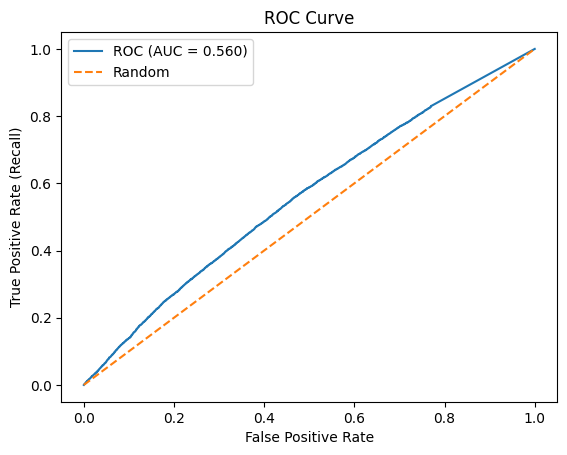

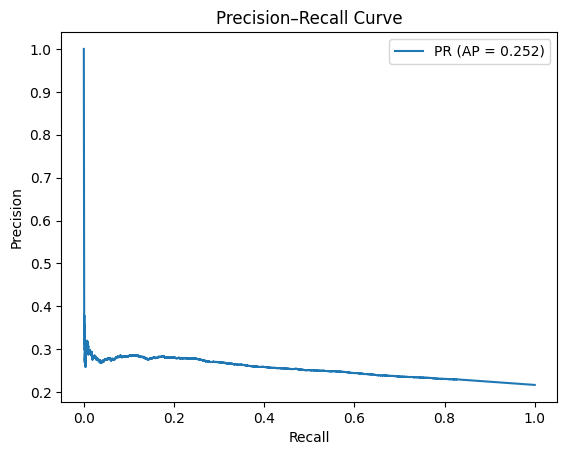

{'accuracy': 0.7516459007956081, 'precision': 0.28295150252900925, 'recall': 0.0939537640782454, 'f1': 0.14106652822072238, 'roc_auc': 0.5596894947568612, 'average_precision': 0.25214489352353425, 'pr_auc_area': 0.25341160726570805}
              precision    recall  f1-score   support

           0       0.79      0.93      0.85     36509
           1       0.28      0.09      0.14     10122

    accuracy                           0.75     46631
   macro avg       0.54      0.51      0.50     46631
weighted avg       0.68      0.75      0.70     46631



In [14]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, auc, confusion_matrix, classification_report)

# --- Train ---
# Create and train KNN model with all main parameters explicitly set
knn = KNeighborsClassifier(
    n_neighbors=7,        # number of neighbors to consider
    weights='distance',    # all neighbors weighted acording to its distace
    algorithm='auto',     # choose the best search algorithm automatically
    leaf_size=30,         # leaf size for BallTree/KDTree
    p=2,                  # Minkowski metric power parameter (p=2 → Euclidean)
    metric='minkowski',   # distance metric
    metric_params=None,   # additional metric parameters
    n_jobs=-1             # use all CPU cores
)

results = evaluate_classifier(knn, X_train, y_train, X_valid, y_valid, plot=True)
print(results["metrics"])
print(results["classification_report"])

Let's try with bagging

In [50]:
from sklearn.ensemble import BaggingClassifier

base_knn = KNeighborsClassifier(
    n_neighbors=3,        # number of neighbors to consider
    weights='distance',    # all neighbors weighted acording to its distace
    algorithm='auto',     # choose the best search algorithm automatically
    leaf_size=30,         # leaf size for BallTree/KDTree
    p=2,                  # Minkowski metric power parameter (p=2 → Euclidean)
    metric='minkowski',   # distance metric
    metric_params=None,   # additional metric parameters
    n_jobs=-1             # use all CPU cores
)

bag_knn = BaggingClassifier(
    estimator=base_knn,
    n_estimators=10,
    max_samples=0.5,
    max_features= 1,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)
bag_knn.fit(X_train, y_train)

# 3) Metrics -------------------------------------------------------------------
proba = bag_knn.predict_proba(X_valid)[:, 1]
y_pred = bag_knn.predict(X_valid)

print(f"Accuracy  : {accuracy_score(y_valid, y_pred):.4f}")
print(f"Precision : {precision_score(y_valid, y_pred, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_valid, y_pred, zero_division=0):.4f}")
print(f"F1-score  : {f1_score(y_valid, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_valid, proba):.4f}\n")

print("=== Classification Report ===")
print(classification_report(y_valid, y_pred, zero_division=0))
print("=== Confusion Matrix ===")
print(confusion_matrix(y_valid, y_pred))
#confusion matrix is predicted values on top and actual values on the left. so
#               Predicted values
#Actual values

Accuracy  : 0.7828
Precision : 0.2857
Recall    : 0.0004
F1-score  : 0.0008
ROC-AUC   : 0.5091

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.78      1.00      0.88     36509
           1       0.29      0.00      0.00     10122

    accuracy                           0.78     46631
   macro avg       0.53      0.50      0.44     46631
weighted avg       0.68      0.78      0.69     46631

=== Confusion Matrix ===
[[36499    10]
 [10118     4]]


The recall is hard to step up, even with this technique. The accuracy and precision do increase. The recall does not and is even lower than previus techniques. It practically lost the ability to capture the true negatives, and is flagging them as positives. Then the highest false positive there could be. This repeats over several neighbors. This could mean that defaulters behave very differently.


# Decision tree and Random Forest

A Decision Tree partitions the feature space into regions by selecting splits that minimize an impurity measure. Creating a tree-like structure where each internal node is a decision rule and each leaf node is a prediction.

Pros: Easy to interpret, handles numerical and categorical data, no feature scaling needed.

Cons: Prone to overfitting and high variance.

For classification, Scikit-learn defaults to the Gini impurity:

$$
G(t)=1-\sum_{k=1}^K p_k^2
$$

where $p_k$ is the proportion of samples in node $t$ belonging to class $k$.
A split is chosen to maximize impurity reduction:

$$
\Delta G=G(t)-\left(\frac{N_L}{N} G\left(t_L\right)+\frac{N_R}{N} G\left(t_R\right)\right)
$$

where $t_L, t_R$ are left/right child nodes and $N_L, N_R$ are their sample counts.
For regression, impurity is measured by variance, and the objective is to minimize this variance.

$$
\operatorname{Var}(t)=\frac{1}{N_t} \sum_{i \in t}\left(y_i-\bar{y}_t\right)^2
$$

A Random Forest is an ensemble of decision trees trained using bagging plus an additional randomization step:
At each split in a tree, only a random subset of features is considered. This reduces correlation between trees, improving generalization.

In Scikit-learn:

- DecisionTreeClassifier / DecisionTreeRegressor: criterion='gini' (default) or 'entropy' for classification criterion='squared_error' for regression. Fully grown unless max_depth, min_samples_split, etc., are set.

- RandomForestClassifier / RandomForestRegressor: Implements bagging + random feature selection automatically.
Controlled by: n_estimators: number of trees. max_features: subset size per split. bootstrap=True: enable bootstrapping (default)

=== Confusion Matrix ===
[[28155  8354]
 [ 7393  2729]]


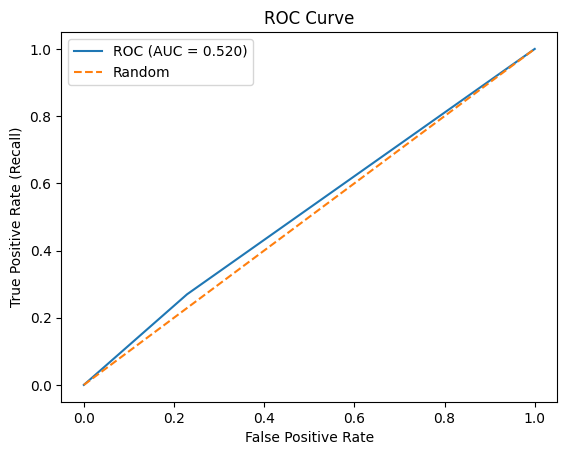

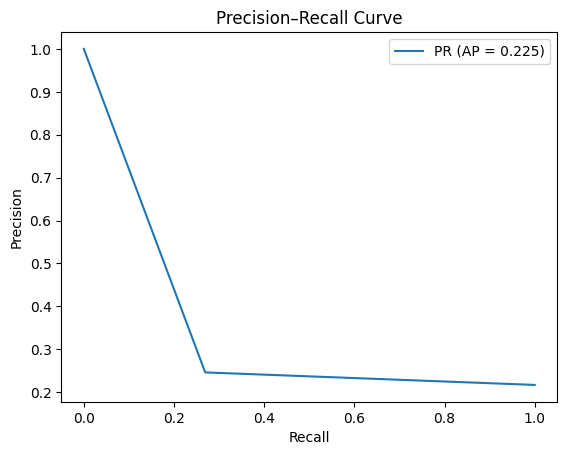

{'accuracy': 0.6623061911603869, 'precision': 0.2462329694126139, 'recall': 0.2696107488638609, 'f1': 0.25739212449893895, 'roc_auc': 0.5203943197599114, 'average_precision': 0.22492818950724325, 'pr_auc_area': 0.33704348439862}
              precision    recall  f1-score   support

           0       0.79      0.77      0.78     36509
           1       0.25      0.27      0.26     10122

    accuracy                           0.66     46631
   macro avg       0.52      0.52      0.52     46631
weighted avg       0.67      0.66      0.67     46631



In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Decision Tree
dt = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=42)
dt.fit(X_train, y_train)


results_dt = evaluate_classifier(dt, X_train, y_train, X_valid, y_valid, plot=True)
print(results_dt["metrics"])
print(results_dt["classification_report"])


=== Confusion Matrix ===
[[35554   955]
 [ 9653   469]]


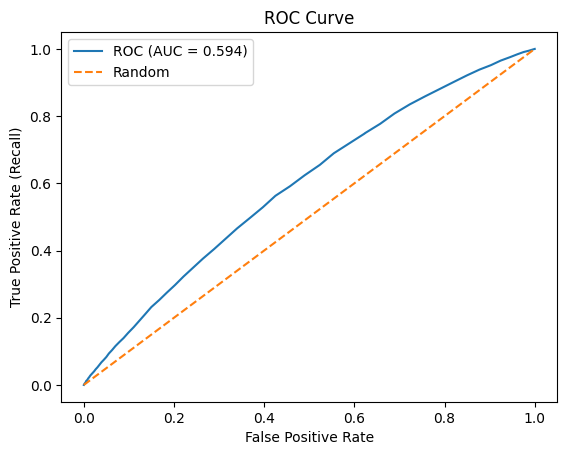

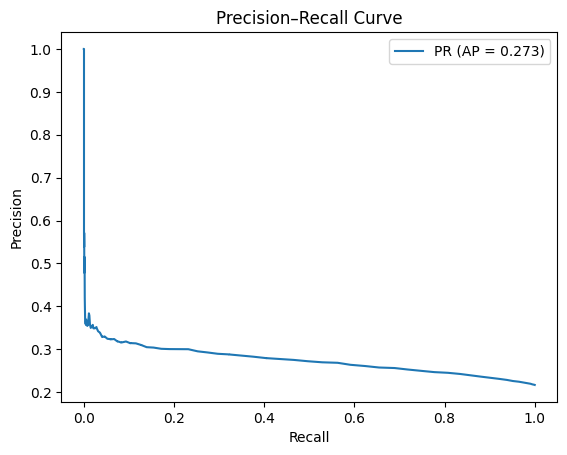

{'accuracy': 0.7725118483412322, 'precision': 0.32935393258426965, 'recall': 0.04633471645919779, 'f1': 0.08124025636584098, 'roc_auc': 0.5935927286815984, 'average_precision': 0.27342663740687206, 'pr_auc_area': 0.2746230549827747}
              precision    recall  f1-score   support

           0       0.79      0.97      0.87     36509
           1       0.33      0.05      0.08     10122

    accuracy                           0.77     46631
   macro avg       0.56      0.51      0.48     46631
weighted avg       0.69      0.77      0.70     46631



In [23]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=100, 
    criterion='gini', 
    max_features='sqrt', 
    bootstrap=True, 
    random_state=42
)
rf.fit(X_train, y_train)

results_rf = evaluate_classifier(rf, X_train, y_train, X_valid, y_valid, plot=True)
print(results_rf["metrics"])
print(results_rf["classification_report"])

The trees get better when using bagging, altough only the decision tree has had a relatively high recall score.

## Boosting

Well introduce all of the algorithms at once, since they all rely on the past one. Well use tree weak learners for all of them, varying only in its implementation.

## Adaboost Adaptative Boosting

Combine multiple weak classifiers $h_m(x)$, trained sequentially, so each new model focuses more on the errors of the previous ones by adjusting sample weights.

Algorithm
1. Initialize weights:

$$
w_i^{(1)}=\frac{1}{N}, \quad i=1, \ldots, N
$$

2. For $m=1, \ldots, M$ :
- Train weak learner $h_m(x)$ minimizing weighted error:

$$
\varepsilon_m=\frac{\sum_{i=1}^N w_i^{(m)} \cdot \mathbf{1}\left(y_i \neq h_m\left(x_i\right)\right)}{\sum_{i=1}^N w_i^{(m)}}
$$

- Compute model weight:

$$
\alpha_m=\frac{1}{2} \ln \left(\frac{1-\varepsilon_m}{\varepsilon_m}\right)
$$

- Update sample weights:

$$
w_i^{(m+1)}=w_i^{(m)} \cdot e^{-\alpha_m y_i h_m\left(x_i\right)}
$$


Normalize so $\sum_i w_i^{(m+1)}=1$.
3. Final model:

$$
H(x)=\operatorname{sign}\left(\sum_{m=1}^M \alpha_m h_m(x)\right)
$$


Notes:
- Works with decision stumps (depth=1) in scikit-learn:
AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=1)).
- Sensitive to outliers because weights can become very large.



=== Confusion Matrix ===
[[29661  6848]
 [ 7729  2393]]


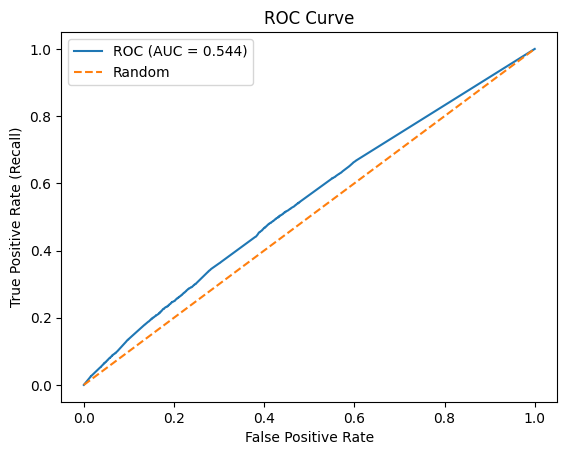

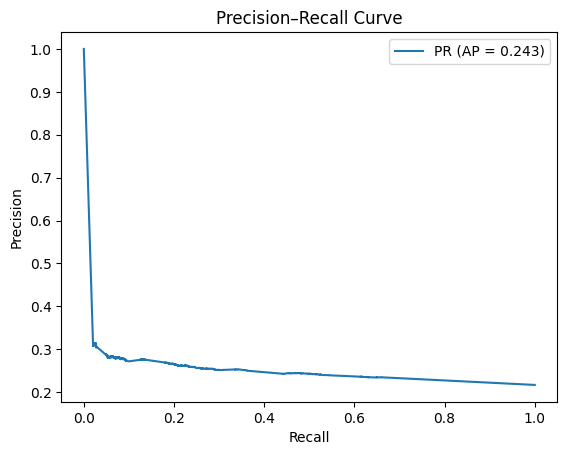

{'accuracy': 0.687396796122751, 'precision': 0.25895465858673306, 'recall': 0.23641572811697292, 'f1': 0.24717244228683571, 'roc_auc': 0.5441960028272458, 'average_precision': 0.2430521208956018, 'pr_auc_area': 0.25372117847838443}
              precision    recall  f1-score   support

           0       0.79      0.81      0.80     36509
           1       0.26      0.24      0.25     10122

    accuracy                           0.69     46631
   macro avg       0.53      0.52      0.52     46631
weighted avg       0.68      0.69      0.68     46631


=== Boosting Rounds ===
Round 1:
  α_m (model weight): 8.6098
error 0.33756513907057545
Round 2:
  α_m (model weight): 9.2457
error 0.3346915142287319
Round 3:
  α_m (model weight): 1.0985
error 0.3353134181124145
Round 4:
  α_m (model weight): 0.7525
error 0.33464862430571923
Round 5:
  α_m (model weight): 0.5006
error 0.33396238553751784
Round 6:
  α_m (model weight): 0.3990
error 0.3354849778044649
Round 7:
  α_m (model weight): 0.33

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier

# Base estimators
dt = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=42)
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs', n_jobs=-1)

# AdaBoost with decision tree as base learner
ada_boost = AdaBoostClassifier(
    estimator=dt,          # base learner
    n_estimators=20,       # number of boosting rounds
    learning_rate=1.0,     # step size
    random_state=42
)


# Evaluate AdaBoost (not rf!)
results_ada_boost = evaluate_classifier(ada_boost, X_train, y_train, X_valid, y_valid, plot=True)

ada_boost = results_ada_boost["model"]
print(results_ada_boost["metrics"])
print(results_ada_boost["classification_report"])

# Access the internals
print("\n=== Boosting Rounds ===")
for m, (est, alpha) in enumerate(zip(ada_boost.estimators_, ada_boost.estimator_weights_), start=1):
    pred = est.predict(X_valid.to_numpy()) #Internal estimator usually drops the features, so we pass an array
    incorrect = (pred != y_valid).astype(int)
    err = np.average(incorrect, weights=ada_boost.estimator_errors_[m-1] * np.ones_like(y_valid))
    
    print(f"Round {m}:")
    print(f"  α_m (model weight): {alpha:.4f}")
    print("error", err)

After 10 rounds the model doesnt get any better. Even so, it has one of the biggest recall and precision among the other candidates. We can try with another model, the log reg.

=== Confusion Matrix ===
[[36500     9]
 [10111    11]]


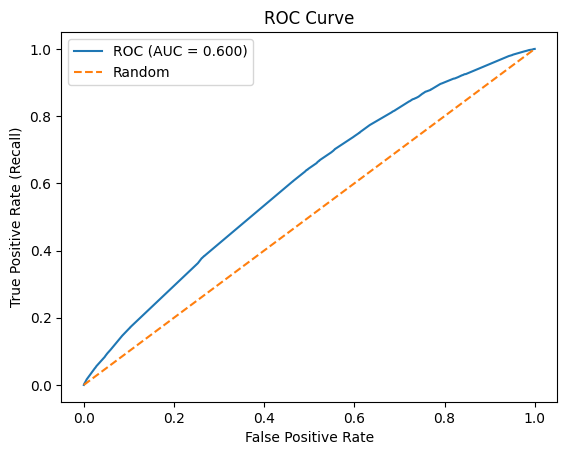

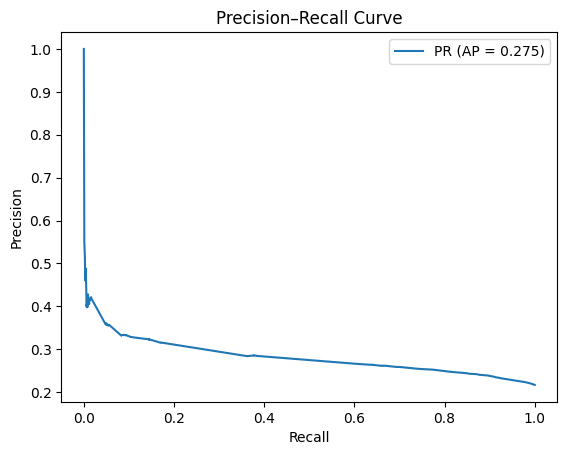

{'accuracy': 0.7829769895563038, 'precision': 0.55, 'recall': 0.0010867417506421656, 'f1': 0.0021691973969631237, 'roc_auc': 0.5998566604086314, 'average_precision': 0.2753029062038, 'pr_auc_area': 0.28267083038214913}
              precision    recall  f1-score   support

           0       0.78      1.00      0.88     36509
           1       0.55      0.00      0.00     10122

    accuracy                           0.78     46631
   macro avg       0.67      0.50      0.44     46631
weighted avg       0.73      0.78      0.69     46631


=== Boosting Rounds ===
Round 1:
  α_m (model weight): 1.2828
error 0.21706590036670884
Round 2:
  α_m (model weight): 0.2635
error 0.5327142887778517
Round 3:
  α_m (model weight): 0.1008
error 0.21974652055499558
Round 4:
  α_m (model weight): 0.1724
error 0.5383757586155131
Round 5:
  α_m (model weight): 0.0720
error 0.23574446183869105
Round 6:
  α_m (model weight): 0.0759
error 0.607171195127705
Round 7:
  α_m (model weight): 0.0606
error 0.228

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier

# Base estimators
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs', n_jobs=-1)

# AdaBoost with decision tree as base learner
ada_boost = AdaBoostClassifier(
    estimator=log_reg,          # base learner
    n_estimators=20,       # number of boosting rounds
    learning_rate=1.0,     # step size
    random_state=42
)


# Evaluate AdaBoost (not rf!)
results_ada_boost = evaluate_classifier(ada_boost, X_train, y_train, X_valid, y_valid, plot=True)

ada_boost = results_ada_boost["model"]
print(results_ada_boost["metrics"])
print(results_ada_boost["classification_report"])

# Access the internals
print("\n=== Boosting Rounds ===")
for m, (est, alpha) in enumerate(zip(ada_boost.estimators_, ada_boost.estimator_weights_), start=1):
    pred = est.predict(X_valid.to_numpy()) #Internal estimator usually drops the features, so we pass an array
    incorrect = (pred != y_valid).astype(int)
    err = np.average(incorrect, weights=ada_boost.estimator_errors_[m-1] * np.ones_like(y_valid))
    
    print(f"Round {m}:")
    print(f"  α_m (model weight): {alpha:.4f}")
    print("error", err)

The log reg is a strong base model, the model weigths more rapidly decay to 0. This version of the model has poor performance. Yet it has a bigger AUC, moving the treshold might hold a better result in this model, altough there is no easy way to do it.

## Gradient Boosting Machine GBM

Instead of reweighting data, fit new models to the negative gradient of the loss function (residuals). This is gradient descent in function space.

Algorithm
1. Initialize with constant model:

$$
F_0(x)=\arg \min _\gamma \sum_{i=1}^N L\left(y_i, \gamma\right)
$$

2. For $m=1, \ldots, M$ :
- Compute pseudo-residuals:

$$
r_{i m}=-\left[\frac{\partial L\left(y_i, F\left(x_i\right)\right)}{\partial F\left(x_i\right)}\right]_{F=F_{m-1}}
$$

- Fit weak learner $h_m(x)$ to $r_{i m}$.
- Compute optimal step size:

$$
\gamma_m=\arg \min _\gamma \sum_{i=1}^N L\left(y_i, F_{m-1}\left(x_i\right)+\gamma h_m\left(x_i\right)\right)
$$

- Update:

$$
F_m(x)=F_{m-1}(x)+\nu \gamma_m h_m(x)
$$

where $\nu$ is the learning rate.
Notes:
- Flexible: any differentiable loss (e.g., logistic loss for classification).
- Only supports trees as base learners
- In scikit-learn: GradientBoostingClassifier(loss="log_loss").

=== Confusion Matrix ===
[[13633 22876]
 [ 2785  7337]]


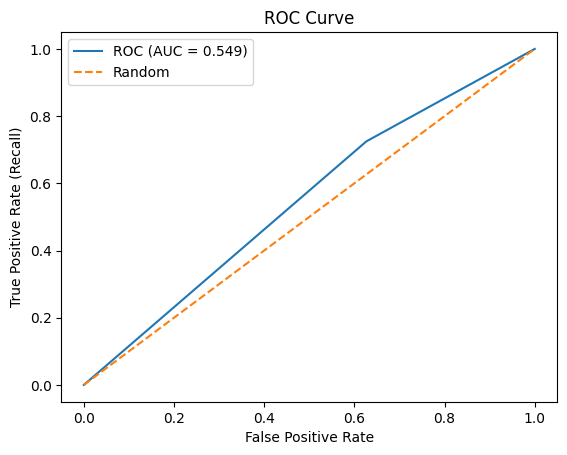

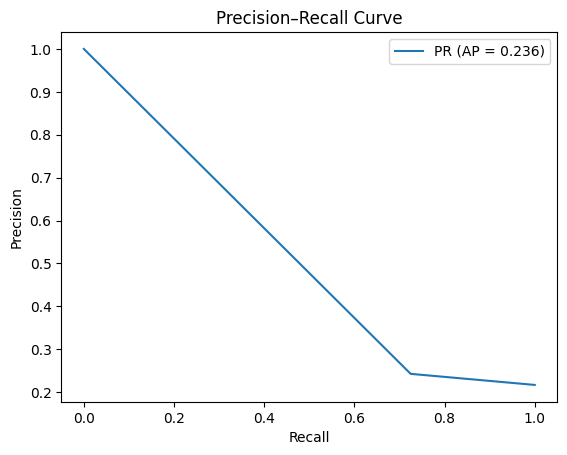

{'accuracy': 0.4497008427869872, 'precision': 0.24284248502300335, 'recall': 0.7248567476783244, 'f1': 0.3638031486302219, 'roc_auc': 0.549135761058752, 'average_precision': 0.2357502316869255, 'pr_auc_area': 0.5137117252481784}
              precision    recall  f1-score   support

           0       0.83      0.37      0.52     36509
           1       0.24      0.72      0.36     10122

    accuracy                           0.45     46631
   macro avg       0.54      0.55      0.44     46631
weighted avg       0.70      0.45      0.48     46631


=== Boosting Rounds (train vs valid) ===
Round 01: train_loss=1.1970  val_loss=0.6007  acc=0.4497
Round 02: train_loss=9.4838  val_loss=4.7334  acc=0.4497
Round 03: train_loss=514602.4749  val_loss=19.8348  acc=0.4497
Round 04: train_loss=514602.4749  val_loss=19.8348  acc=0.4497
Round 05: train_loss=514602.4749  val_loss=19.8348  acc=0.4497
Round 06: train_loss=514602.4749  val_loss=19.8348  acc=0.4497
Round 07: train_loss=514602.4749  va

In [47]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss, accuracy_score
# Base estimators only trees up to 3 depth

# AdaBoost with decision tree as base learner
GBM = GradientBoostingClassifier(loss='log_loss',
                                 n_estimators=20,
                                 learning_rate=6,
                                 random_state=42,
                                 max_depth= 1
                                 )

# Evaluate
GBM_results = evaluate_classifier(GBM, X_train, y_train, X_valid, y_valid, plot=True)

GBM = GBM_results["model"]
print(GBM_results["metrics"])
print(GBM_results["classification_report"])

# --- Inspect boosting rounds (GBM-specific) ---
print("\n=== Boosting Rounds (train vs valid) ===")
best_m, best_val_loss = None, float("inf")

for m, proba in enumerate(GBM.staged_predict_proba(X_valid), start=1):
    # Training loss after m-th stage (already averaged deviance)
    train_loss_m = GBM.train_score_[m-1]

    # Validation metrics after m-th stage
    val_loss_m = log_loss(y_valid, proba)
    y_pred_m = GBM.predict(X_valid)
    acc_m = accuracy_score(y_valid, y_pred_m)

    if val_loss_m < best_val_loss:
        best_val_loss, best_m = val_loss_m, m

    print(f"Round {m:02d}: train_loss={train_loss_m:.4f}  val_loss={val_loss_m:.4f}  acc={acc_m:.4f}")

print(f"\nBest validation step (by log_loss): m={best_m} with val_loss={best_val_loss:.4f}")


Awful performance in this case. The learning rate needs to be adjusted to improve the performance, and actually ends with awfull error rate when trying to adjust for the false negatives.

## XGBoost

Extend GBM with second-order Taylor approximation, regularization, and system optimizations.

Objective Function
We minimize:

$$
\mathcal{L}^{(t)} \approx \sum_{i=1}^N\left[g_i f_t\left(x_i\right)+\frac{1}{2} h_i f_t^2\left(x_i\right)\right]+\Omega\left(f_t\right)
$$

where:
- $g_i=\frac{\partial L\left(y_i \hat{y}_i^{(t-1)}\right)}{\partial \hat{y}_i^{(t-1)}}$ (first derivative)
- $h_i=\frac{\partial^2 L\left(y_i, \hat{y}_i^{(t-1)}\right)}{\partial\left(\hat{y}_i^{(t-1)}\right)^2}$ (second derivative)
- Regularization:

$$
\Omega\left(f_t\right)=\gamma T+\frac{\lambda}{2} \sum_{j=1}^T w_j^2
$$

where $T=$ number of leaves, $w_j=$ leaf weight.
Optimal leaf weight
For each leaf $j$ :

$$
w_j^*=-\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i+\lambda}
$$


Gain from split:

$$
\text { Gain }=\frac{1}{2}\left[\frac{\left(\sum_{i \in I_L} g_i\right)^2}{\sum_{i \in I_L} h_i+\lambda}+\frac{\left(\sum_{i \in I_R} g_i\right)^2}{\sum_{i \in I_R} h_i+\lambda}-\frac{\left(\sum_{i \in I} g_i\right)^2}{\sum_{i \in I} h_i+\lambda}\right]-\gamma
$$


Notes:
- Handles missing values, supports column subsampling.
- In Python: xgboost.XGBClassifier().

In [61]:
from xgboost import XGBClassifier
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import numpy as np

# --- Model ---
xgb = XGBClassifier(
    n_estimators=20,           # Total trees
    learning_rate=2,          # Shrinkage factor
    max_depth=2,                # Tree depth
    subsample=0.8,               # Row sampling
    colsample_bytree=0.8,        # Feature sampling
    reg_lambda=1.0,              # L2 regularization
    objective="binary:logistic", # Binary classification (probabilities)
    eval_metric=["logloss", "auc", "aucpr"],  # Track metrics
    n_jobs=-1,                   # All CPU cores
    random_state=42
)

# --- Fit ---
xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=False
)

# --- Direct predictions ---
y_pred = xgb.predict(X_valid)
y_proba = xgb.predict_proba(X_valid)[:, 1]

# --- Metrics ---
acc = accuracy_score(y_valid, y_pred)
prec = precision_score(y_valid, y_pred, zero_division=0)
rec = recall_score(y_valid, y_pred, zero_division=0)
f1 = f1_score(y_valid, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_valid, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}\n")

print("=== Classification Report ===")
print(classification_report(y_valid, y_pred, zero_division=0))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_valid, y_pred))

# --- Inspect boosting rounds (XGBoost-specific) ---
print("\n=== Boosting Rounds (train vs valid) ===")
ev = xgb.evals_result()
train_logloss = ev["validation_0"]["logloss"]
valid_logloss = ev["validation_1"]["logloss"]

best_m, best_val_loss = None, float("inf")
n_rounds = len(valid_logloss)

for m in range(1, n_rounds + 1):
    try:
        proba_m = xgb.predict_proba(X_valid, iteration_range=(0, m))[:, 1]
    except TypeError:
        proba_m = xgb.predict_proba(X_valid, ntree_limit=m)[:, 1]

    y_pred_m = (proba_m >= 0.5).astype(int)
    acc_m = accuracy_score(y_valid, y_pred_m)
    val_loss_m = log_loss(y_valid, proba_m)

    if val_loss_m < best_val_loss:
        best_val_loss, best_m = val_loss_m, m

    train_loss_m = train_logloss[m - 1]
    valid_loss_m = valid_logloss[m - 1]
    print(f"Round {m:03d}: train_loss={train_loss_m:.4f}  valid_loss(tracked)={valid_loss_m:.4f}  "
          f"valid_loss(recalc)={val_loss_m:.4f}  acc={acc_m:.4f}")

print(f"\nBest validation step (by log_loss): m={best_m} with val_loss={best_val_loss:.4f}")


Accuracy : 0.7317
Precision: 0.1948
Recall   : 0.0754
F1-score : 0.1087
ROC-AUC  : 0.5447

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.78      0.91      0.84     36509
           1       0.19      0.08      0.11     10122

    accuracy                           0.73     46631
   macro avg       0.49      0.49      0.48     46631
weighted avg       0.65      0.73      0.68     46631

=== Confusion Matrix ===
[[33355  3154]
 [ 9359   763]]

=== Boosting Rounds (train vs valid) ===
Round 001: train_loss=0.5225  valid_loss(tracked)=0.5232  valid_loss(recalc)=0.5232  acc=0.7829
Round 002: train_loss=0.5254  valid_loss(tracked)=0.5269  valid_loss(recalc)=0.5269  acc=0.7829
Round 003: train_loss=0.5236  valid_loss(tracked)=0.5242  valid_loss(recalc)=0.5242  acc=0.7829
Round 004: train_loss=0.5278  valid_loss(tracked)=0.5293  valid_loss(recalc)=0.5293  acc=0.7829
Round 005: train_loss=0.5248  valid_loss(tracked)=0.5253  valid_loss(r

The same behavior as the past one, the errors grow when trying to adjust for the false negatives.

## Catboost

CatBoost is a gradient boosting library that’s great with categorical features and avoids common leaks/overfitting pitfalls via two key ideas:

1) Ordered target statistics (a.k.a. ordered target encoding)

For a categorical feature $x_k$ and sample order (a permutation) $\pi$, CatBoost encodes category values using only earlier samples, preventing target leakage:

$$
\operatorname{Enc}\left(x_{i, k}\right)=\frac{\sum_{j: \pi(j)<\pi(i)} \mathbf{1}\left(x_{j, k}=x_{i, k}\right) y_j+a \cdot P}{\sum_{j: \pi(j)<\pi(i)} \mathbf{1}\left(x_{j, k}=x_{i, k}\right)+a}
$$

- $a$ : smoothing prior weight
- $\quad P$ : prior (e.g., overall mean target)
- Multiple permutations are used; encodings are averaged $\rightarrow$ robust $\&$ leak-free.
2) Ordered boosting

During boosting, gradients for sample $i$ at iteration $t$ are computed using a model trained only on earlier samples in the permutation, reducing "prediction shift" (optimistic bias from using the same data to compute targets and gradients).

3) Oblivious (symmetric) trees

CatBoost grows symmetric trees: each level uses one split rule applied to all leaves at that depth.
- Depth $d$ yields exactly $2^d$ leaves with the same path length.
- Benefits: strong regularization, compact models, fast inference on CPU/GPU.

4) Loss \& update (like GBMs)

CatBoost minimizes a differentiable loss (e.g., Logloss for binary):

$$
F_t(x)=F_{t-1}(x)+\eta \cdot h_t(x)
$$

where $h_t$ is the new tree fit to (ordered) pseudo-residuals / gradients, and $\eta$ is learning_rate . Regularization includes 12_leaf_reg, depth limits, feature sampling, etc.

Practical perks
- Native categorical support (no manual one-hot/target encoding needed).
- Handles missing values and unseen categories gracefully.
- Strong defaults; less hyperparam fiddling than many GBMs.

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix, log_loss)
import numpy as np

# --- Model ---
cbc = CatBoostClassifier(
    iterations=300,              # total boosting rounds
    learning_rate=1,           # shrinkage
    depth=6,                     # tree depth (symmetric trees)
    loss_function="Logloss",     # binary logistic loss
    eval_metric="Logloss",       # metric to track; add 'AUC' too if you like
    l2_leaf_reg=3.0,             # L2 regularization on leaf values
    random_seed=42,
    verbose=False               # silence per-iter logging
    #class_weights="balanced",    # optional: handle imbalance
)

# --- Fit with validation to track per-iteration metrics ---
cbc.fit(
    X_train, y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=False,
    train_dir=None# keep full training; set True if you enable early stopping
    # early_stopping_rounds=50,  # optional: stop early on no improvement
)

# --- Direct predictions & metrics ---
y_pred  = cbc.predict(X_valid)                   # hard labels (0/1)
y_proba = cbc.predict_proba(X_valid)[:, 1]       # probabilities

acc = accuracy_score(y_valid, y_pred)
prec = precision_score(y_valid, y_pred, zero_division=0)
rec = recall_score(y_valid, y_pred, zero_division=0)
f1 = f1_score(y_valid, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_valid, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}\n")
print("=== Classification Report ===")
print(classification_report(y_valid, y_pred, zero_division=0))
print("=== Confusion Matrix ===")
print(confusion_matrix(y_valid, y_pred))

# --- Per-iteration diagnostics ---
print("\n=== Boosting Rounds (train vs valid) ===")
ev = cbc.get_evals_result()
train_loss = ev["learn"]["Logloss"]
valid_loss = ev["validation"]["Logloss"] #if "validation" in ev else ev["validation_0"]["Logloss"]

best_m, best_val = None, float("inf")
for m in range(1, cbc.tree_count_ + 1):
    # predict using only the first m trees
    proba_m = cbc.predict(X_valid, prediction_type="Probability", ntree_end=m).ravel()
    y_pred_m = cbc.predict(X_valid)
    acc_m = accuracy_score(y_valid, y_pred_m)

    print(f"Round {m:03d}: train_loss={train_loss[m-1]:.4f}  valid_loss(tracked)={valid_loss[m-1]:.4f}  ")

print(f"\nBest validation step (by log_loss): m={best_m}  val_loss={best_val:.4f}")


Accuracy : 0.7681
Precision: 0.3166
Recall   : 0.0591
F1-score : 0.0996
ROC-AUC  : 0.5929

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.79      0.96      0.87     36509
           1       0.32      0.06      0.10     10122

    accuracy                           0.77     46631
   macro avg       0.55      0.51      0.48     46631
weighted avg       0.68      0.77      0.70     46631

=== Confusion Matrix ===
[[35218  1291]
 [ 9524   598]]

=== Boosting Rounds (train vs valid) ===
Round 001: train_loss=0.5117  valid_loss(tracked)=0.5123  
Round 002: train_loss=0.5081  valid_loss(tracked)=0.5101  
Round 003: train_loss=0.5066  valid_loss(tracked)=0.5097  
Round 004: train_loss=0.5057  valid_loss(tracked)=0.5092  
Round 005: train_loss=0.5051  valid_loss(tracked)=0.5087  
Round 006: train_loss=0.5045  valid_loss(tracked)=0.5083  
Round 007: train_loss=0.5039  valid_loss(tracked)=0.5082  
Round 008: train_loss=0.5036  valid_loss(

Same as the steps before, its a class imbalance thing then.

## XG Boost and Random Forest with class imbalance handling.

In [71]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
import numpy as np

# --- Helper: evaluate at different thresholds ---
def evaluate_with_threshold(y_true, y_proba, thresholds):
    results = []
    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        results.append((thr, acc, prec, rec, f1))
    return results

# --- Class imbalance ratios ---
pos_ratio = np.sum(y_train == 0) / np.sum(y_train == 1)  # n_negatives / n_positives

# =====================
# 1. XGBoost
# =====================
xgb = XGBClassifier(
    n_estimators=100,            # more trees
    learning_rate=0.1,          # smaller learning rate
    max_depth=3,                 # deeper trees
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=pos_ratio   # balance classes
)
xgb.fit(X_train, y_train)

y_proba_xgb = xgb.predict_proba(X_valid)[:, 1]

# Threshold tuning
thresholds = np.linspace(0.1, 0.9, 9)
xgb_results = evaluate_with_threshold(y_valid, y_proba_xgb, thresholds)

print("\n=== XGBoost Threshold Sweep ===")
for thr, acc, prec, rec, f1 in xgb_results:
    print(f"thr={thr:.2f}  acc={acc:.3f}  prec={prec:.3f}  rec={rec:.3f}  f1={f1:.3f}")

# =====================
# 2. Random Forest
# =====================
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight="balanced",   # balance classes
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_proba_rf = rf.predict_proba(X_valid)[:, 1]

# Threshold tuning
rf_results = evaluate_with_threshold(y_valid, y_proba_rf, thresholds)

print("\n=== Random Forest Threshold Sweep ===")
for thr, acc, prec, rec, f1 in rf_results:
    print(f"thr={thr:.2f}  acc={acc:.3f}  prec={prec:.3f}  rec={rec:.3f}  f1={f1:.3f}")



=== XGBoost Threshold Sweep ===
thr=0.10  acc=0.218  prec=0.217  rec=1.000  f1=0.357
thr=0.20  acc=0.228  prec=0.219  rec=0.997  f1=0.359
thr=0.30  acc=0.274  prec=0.227  rec=0.977  f1=0.369
thr=0.40  acc=0.411  prec=0.250  rec=0.856  f1=0.387
thr=0.50  acc=0.555  prec=0.278  rec=0.657  f1=0.391
thr=0.60  acc=0.736  prec=0.330  rec=0.209  f1=0.256
thr=0.70  acc=0.781  prec=0.420  rec=0.025  f1=0.047
thr=0.80  acc=0.783  prec=0.450  rec=0.001  f1=0.002
thr=0.90  acc=0.783  prec=0.000  rec=0.000  f1=0.000

=== Random Forest Threshold Sweep ===
thr=0.10  acc=0.330  prec=0.232  rec=0.904  f1=0.369
thr=0.20  acc=0.538  prec=0.259  rec=0.609  f1=0.364
thr=0.30  acc=0.694  prec=0.291  rec=0.284  f1=0.288
thr=0.40  acc=0.750  prec=0.305  rec=0.119  f1=0.171
thr=0.50  acc=0.774  prec=0.330  rec=0.040  f1=0.072
thr=0.60  acc=0.781  prec=0.369  rec=0.012  f1=0.024
thr=0.70  acc=0.783  prec=0.367  rec=0.002  f1=0.004
thr=0.80  acc=0.783  prec=0.500  rec=0.001  f1=0.002
thr=0.90  acc=0.783  prec=0

## Resampling with SMOTE Synthetic Minority Oversampling Technique

It's a popular method to handle class imbalance in classification problems - instead of just duplicating minority samples, it creates synthetic ones.

How it works
Let's say your dataset has:
- Majority class (non-defaulters): 90\%
- Minority class (defaulters): $10 \%$

A naive approach would be to just duplicate existing minority points (oversampling), but that risks overfitting.
SMOTE improves on this by generating new samples along the lines between existing minority samples and their neighbors.

Steps:
1. Pick a minority class sample $x_i$.
2. Find its $k$-nearest minority neighbors (often $k=5$ ).
3. Randomly choose one neighbor $x_{n n}$.
4. Create a synthetic sample:

$$
x_{\text {new }}=x_i+\lambda \cdot\left(x_{n n}-x_i\right)
$$

where $\lambda \in[0,1]$ is a random number.
This produces new points inside the minority class space, filling gaps and making the boundary with the majority class smoother.

When to use
- Binary classification with a strong imbalance.
- When you want to improve recall of the minority class.
- Before training models sensitive to class imbalance (logistic regression, KNN, SVM, boosting, etc.).

In [77]:
import os
os.environ["SKLEARN_ARRAY_API"] = "0"

In [79]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- Apply SMOTE only to training set ---
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_valid)
print("\nRandom Forest:\n")
print(classification_report(y_valid, y_pred_rf))
print(confusion_matrix(y_valid, y_pred_rf))

# --- XGBoost ---
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.5,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="binary:logistic",
    n_jobs=-1,
    random_state=42
)
xgb.fit(X_train_res, y_train_res)
y_pred_xgb = xgb.predict(X_valid)
print("\nXGBoost:\n")
print(classification_report(y_valid, y_pred_xgb))
print(confusion_matrix(y_valid, y_pred_xgb))



Random Forest:

              precision    recall  f1-score   support

           0       0.79      0.93      0.86     36509
           1       0.31      0.11      0.16     10122

    accuracy                           0.75     46631
   macro avg       0.55      0.52      0.51     46631
weighted avg       0.69      0.75      0.70     46631

[[34025  2484]
 [ 9024  1098]]

XGBoost:

              precision    recall  f1-score   support

           0       0.79      0.93      0.85     36509
           1       0.30      0.11      0.16     10122

    accuracy                           0.75     46631
   macro avg       0.54      0.52      0.51     46631
weighted avg       0.68      0.75      0.70     46631

[[33931  2578]
 [ 9020  1102]]


it seems that the class imbalance is the main problem with this dataset.